
# Phase8~13 Experimental Results Notebook (Architecture Evidence)

이 노트북은 `phase8_13_final_architecture.md`의 추천이 왜 합리적인지, 실험 결과를 기반으로 시각화해서 보여주기 위한 자료입니다.

- 플롯의 텍스트는 **영어만** 사용합니다(한글 폰트 깨짐 방지).
- 설명은 각 섹션의 마크다운 셀에서 한국어로 제공합니다.
- 핵심 포인트:
  - 축별(top settings) 성능 비교
  - final 3 architecture recipe 근거 비교
  - special(cold/short) 시각화
  - diag ↔ 성능 관계(전체/축내 상대지표 포함)


In [ ]:

# If needed, uncomment the next line.
# !pip install -q pandas matplotlib seaborn

import os
import json
import re
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10



## 데이터 로딩 및 전처리

- 대상: `P8~P13` wide + verification 완료 run
- source:
  - `diag_special_join.csv` (P8)
  - `wide_all_9_13.csv`
  - `verification_all_9_13.csv`
- `special_metrics.json`이 있으면 valid/test special slice(`cold<=5`, `short 1-2`)를 함께 읽습니다.
- 이후 축(architecture axis) 단위 상대지표를 만듭니다.


In [ ]:

BASE_DIR = '/workspace/jy1559/FMoE/experiments/run/fmoe_n3/docs'
P8_PATH = f'{BASE_DIR}/data/phase8_9/diag_special_join.csv'
WIDE_PATH = f'{BASE_DIR}/final/data/phase9_13_wrapup/wide_all_9_13.csv'
VER_PATH = f'{BASE_DIR}/final/data/phase9_13_wrapup/verification_all_9_13.csv'

AXIS_META = {
    'P8-SCR-A': ('P8 wrapper_combo', 'Router/Wrapper'),
    'P8-SCR-B': ('P8 bias_mode', 'Router/Bias'),
    'P8-SCR-C': ('P8 source_profile', 'Router/Source'),
    'P8-SCR-D': ('P8 topk_profile', 'Router/TopK'),
    'P8-CFM': ('P8 confirmation', 'Router/Verification'),
    'P8-VER-BASE-A': ('P8 verification A', 'Router/Verification'),
    'P8-VER-BASE-B': ('P8 verification B', 'Router/Verification'),
    'P8-VER-BASE-C': ('P8 verification C', 'Router/Verification'),
    'P8-VER-BASE-D': ('P8 verification D', 'Router/Verification'),
    'P9-C0': ('P9 natural', 'Aux Concept'),
    'P9-C1': ('P9 canonical balance', 'Aux Concept'),
    'P9-C2': ('P9 specialization', 'Aux Concept'),
    'P9-C3': ('P9 feature alignment', 'Aux Concept'),
    'P9_2-K1': ('P9_2 K1', 'Aux Verification'),
    'P9_2-K2': ('P9_2 K2', 'Aux Verification'),
    'P9_2-K3': ('P9_2 K3', 'Aux Verification'),
    'P10-group_subset': ('P10 feature_subset', 'Feature'),
    'P10-compactness': ('P10 compactness', 'Feature'),
    'P10-availability': ('P10 availability', 'Feature'),
    'P10-stochastic': ('P10 stochastic', 'Feature'),
    'P10-availability_plus': ('P10 availability_plus', 'Feature'),
    'P10-compactness_plus': ('P10 compactness_plus', 'Feature'),
    'P11-base_ablation': ('P11 base_ablation', 'Stage/Layout'),
    'P11-routing_granularity': ('P11 routing_granularity', 'Stage/Layout'),
    'P11-order_permutation': ('P11 order_permutation', 'Stage/Layout'),
    'P11-extra_alignment': ('P11 extra_alignment', 'Stage/Layout'),
    'P11-prepend_layer': ('P11 prepend_layer', 'Stage/Layout'),
    'P12-layout_variants': ('P12 layout_variants', 'Stage/Layout'),
    'P12-bundle_chain': ('P12 bundle_chain', 'Stage/Layout'),
    'P12-bundle_pair_then_follow': ('P12 bundle_pair_then_follow', 'Stage/Layout'),
    'P12-bundle_all': ('P12 bundle_all', 'Stage/Layout'),
    'P12-bundle_router': ('P12 bundle_router', 'Stage/Layout'),
    'P13-data_condition': ('P13 data_condition', 'Sanity'),
    'P13-eval_perturb': ('P13 eval_perturb', 'Sanity'),
    'P13-eval_perturb_extra': ('P13 eval_perturb_extra', 'Sanity'),
    'P13-train_corruption': ('P13 train_corruption', 'Sanity'),
    'P13-semantic_mismatch': ('P13 semantic_mismatch', 'Sanity'),
    'P13-train_shift_extra': ('P13 train_shift_extra', 'Sanity'),
}

DIAG_COLS = {
    'diag_n_eff': 'n_eff',
    'diag_cv_usage': 'cv',
    'diag_entropy_mean': 'ent',
    'diag_top1_max_frac': 'top1',
    'diag_route_consistency_knn_score': 'expert_nn',
    'diag_route_consistency_group_knn_score': 'group_nn',
    'diag_route_consistency_intra_group_knn_mean_score': 'intra_nn',
    'diag_route_consistency_feature_group_knn_mean_score': 'feat_nn',
    'diag_route_consistency_feature_group_knn_tempo_score': 'tempo_nn',
    'diag_route_consistency_feature_group_knn_focus_score': 'focus_nn',
    'diag_route_consistency_feature_group_knn_memory_score': 'memory_nn',
    'diag_route_consistency_feature_group_knn_exposure_score': 'exposure_nn',
}


def axis_of(row, phase):
    rp = str(row.get('run_phase', ''))
    if phase == 'P8':
        if rp.startswith('P8_SCR_'):
            m = re.match(r'^P8_SCR_([A-Z]+)_', rp)
            return f"P8-SCR-{m.group(1) if m else 'SCR'}"
        if rp.startswith('P8_CFM_'):
            return 'P8-CFM'
        if rp.startswith('P8_2_'):
            m = re.match(r'^P8_2_([A-D])_', rp)
            return f"P8-VER-BASE-{m.group(1) if m else 'X'}"
        return 'P8-OTHER'
    if phase == 'P9':
        return f"P9-{row.get('axis_group') or 'UNK'}"
    if phase == 'P9_2':
        return f"P9_2-{row.get('axis_group') or 'UNK'}"
    sg = (row.get('setting_group') or '').strip() or 'UNGROUPED'
    return f"{phase}-{sg}"


def _to_float(x):
    try:
        if pd.isna(x):
            return np.nan
        return float(x)
    except Exception:
        return np.nan


@lru_cache(None)
def load_special_json(path):
    if not path or not os.path.exists(path):
        return {}
    try:
        with open(path, 'r', encoding='utf-8') as f:
            return json.load(f)
    except Exception:
        return {}


def path_get(d, keys):
    cur = d
    for k in keys:
        if not isinstance(cur, dict):
            return np.nan
        cur = cur.get(k)
    try:
        return float(cur)
    except Exception:
        return np.nan


def special_path_of(row):
    p = str(row.get('special_path', '') or '').strip()
    if p and os.path.exists(p):
        return p
    rd = str(row.get('run_dir', '') or '').strip()
    if rd:
        cand = os.path.join(rd, 'special_metrics.json')
        if os.path.exists(cand):
            return cand
    return ''


p8 = pd.read_csv(P8_PATH)
p8 = p8[p8['run_phase'].astype(str).str.startswith('P8')]
p8 = p8[p8['status'].astype(str).str.lower().isin(['completed', 'run_complete'])].copy()
p8['source_phase'] = 'P8'
p8['profile'] = np.where(p8['run_phase'].astype(str).str.startswith('P8_2_'), 'verification', 'wide')

w = pd.read_csv(WIDE_PATH)
v = pd.read_csv(VER_PATH)

for d, prof in [(w, 'wide'), (v, 'verification')]:
    d['profile'] = prof

all_df = pd.concat([p8, w, v], ignore_index=True, sort=False)
all_df = all_df[all_df['source_phase'].astype(str).isin(['P8','P9','P9_2','P10','P11','P12','P13'])].copy()
mask_done = all_df['status'].astype(str).str.lower().isin(['completed', 'run_complete']) | (all_df.get('trigger', '').astype(str).str.lower() == 'run_complete')
all_df = all_df[mask_done].copy()

all_df['axis'] = [axis_of(r, p) for r, p in zip(all_df.to_dict('records'), all_df['source_phase'])]
all_df['axis_label'] = all_df['axis'].map(lambda x: AXIS_META.get(x, (x, 'Other'))[0])
all_df['axis_family'] = all_df['axis'].map(lambda x: AXIS_META.get(x, (x, 'Other'))[1])
all_df['setting_key'] = all_df.get('setting_key', pd.Series(index=all_df.index, dtype='object')).fillna(all_df.get('setting_id', '')).fillna(all_df.get('run_phase', ''))
all_df['setting_short'] = all_df.get('setting_short', pd.Series(index=all_df.index, dtype='object')).fillna(all_df.get('setting_id', '')).fillna(all_df['setting_key'])

for col, new_col in [('best_valid_mrr20','valid'), ('test_mrr20','test'), ('cold_item_mrr20','cold_core'), ('sess_1_2_mrr20','short_core')]:
    all_df[new_col] = all_df[col].map(_to_float)

for raw, alias in DIAG_COLS.items():
    if raw in all_df.columns:
        all_df[alias] = all_df[raw].map(_to_float)
    else:
        all_df[alias] = np.nan

# Special metrics from JSON when available
valid_spec_overall = []
test_spec_overall = []
valid_low = []
test_low = []
valid_s12 = []
test_s12 = []

for row in all_df.to_dict('records'):
    sp = special_path_of(row)
    obj = load_special_json(sp) if sp else {}
    bv = obj.get('best_valid_special_metrics', {}) if isinstance(obj, dict) else {}
    tv = obj.get('test_special_metrics', {}) if isinstance(obj, dict) else {}

    valid_spec_overall.append(path_get(bv, ['overall', 'mrr@20']))
    test_spec_overall.append(path_get(tv, ['overall', 'mrr@20']))
    valid_low.append(path_get(bv, ['slices', 'target_popularity_abs', '<=5', 'mrr@20']))
    test_low.append(path_get(tv, ['slices', 'target_popularity_abs', '<=5', 'mrr@20']))
    valid_s12.append(path_get(bv, ['slices', 'session_len', '1-2', 'mrr@20']))
    test_s12.append(path_get(tv, ['slices', 'session_len', '1-2', 'mrr@20']))

all_df['valid_spec_overall'] = valid_spec_overall
all_df['test_spec_overall'] = test_spec_overall
all_df['valid_low'] = valid_low
all_df['test_low'] = test_low
all_df['valid_s12'] = valid_s12
all_df['test_s12'] = test_s12

# Relative metrics to reduce cross-axis confound
for m in ['valid', 'test', 'test_low', 'test_s12']:
    g = all_df.groupby('axis')[m]
    all_df[f'{m}_centered_axis'] = all_df[m] - g.transform('mean')
    all_df[f'{m}_rank_axis_pct'] = g.rank(method='average', pct=True)


def _zscore_in_axis(s):
    std = s.std(ddof=0)
    if pd.isna(std) or std == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.mean()) / std

all_df['valid_z_axis'] = all_df.groupby('axis')['valid'].transform(_zscore_in_axis)
all_df['test_z_axis'] = all_df.groupby('axis')['test'].transform(_zscore_in_axis)
all_df['test_low_z_axis'] = all_df.groupby('axis')['test_low'].transform(_zscore_in_axis)
all_df['test_s12_z_axis'] = all_df.groupby('axis')['test_s12'].transform(_zscore_in_axis)
all_df['composite_axis_score'] = (
    0.25 * all_df['valid_z_axis'].fillna(0)
    + 0.40 * all_df['test_z_axis'].fillna(0)
    + 0.20 * all_df['test_low_z_axis'].fillna(0)
    + 0.15 * all_df['test_s12_z_axis'].fillna(0)
)

print('Rows:', len(all_df))
print('Phases:', sorted(all_df['source_phase'].unique()))
print('Axis count:', all_df['axis'].nunique())


Rows: 532
Phases: ['P10', 'P11', 'P12', 'P13', 'P8', 'P9', 'P9_2']
Axis count: 38



## 기본 집계 확인

이 셀은 phase/axis별 샘플 수를 보고 데이터 편향(특정 축만 run 수가 많은지)을 먼저 점검합니다.


In [ ]:

phase_counts = all_df.groupby('source_phase').size().rename('n').reset_index().sort_values('source_phase')
axis_counts = all_df.groupby(['axis_family', 'axis_label']).size().rename('n').reset_index().sort_values(['axis_family', 'n'], ascending=[True, False])

print('Phase counts')
display(phase_counts)
print('Top axis counts')
display(axis_counts.head(20))


Phase counts


,source_phase,n
0,P10,118
1,P11,56
2,P12,64
3,P13,54
4,P8,130
5,P9,63
6,P9_2,47


Top axis counts


,axis_family,axis_label,n
0,Aux Concept,P9 canonical balance,16
2,Aux Concept,P9 natural,16
3,Aux Concept,P9 specialization,16
1,Aux Concept,P9 feature alignment,15
4,Aux Verification,P9_2 K1,16
5,Aux Verification,P9_2 K2,16
6,Aux Verification,P9_2 K3,15
11,Feature,P10 feature_subset,39
9,Feature,P10 compactness,27
7,Feature,P10 availability,18



## 축별 Top settings (test-aware composite)

- 각 axis 안에서 setting별 평균을 만들고,
- `0.25*valid + 0.40*test + 0.20*cold<=5 + 0.15*short1-2` (축내 z-score) 기준으로 top-3를 뽑습니다.
- 이 표가 final architecture 선택의 1차 근거입니다.


In [ ]:

agg_cols = ['valid','test','test_low','test_s12','n_eff','ent','top1','intra_nn','feat_nn','group_nn','composite_axis_score']
summary = (
    all_df.groupby(['axis','axis_family','axis_label','setting_short'], dropna=False)
    [agg_cols]
    .mean(numeric_only=True)
    .reset_index()
)
summary['n_runs'] = all_df.groupby(['axis','axis_family','axis_label','setting_short']).size().values

summary['rank_in_axis'] = summary.groupby('axis')['composite_axis_score'].rank(method='first', ascending=False)
top3 = summary[summary['rank_in_axis'] <= 3].copy()
top3 = top3.sort_values(['axis_family','axis_label','rank_in_axis'])

show_cols = ['axis_family','axis_label','rank_in_axis','setting_short','n_runs','valid','test','test_low','test_s12','composite_axis_score']
display(top3[show_cols].head(120))


,axis_family,axis_label,rank_in_axis,setting_short,n_runs,valid,test,test_low,test_s12,composite_axis_score
188,Aux Concept,P9 canonical balance,1.0,B2,4,0.080575,0.161250,0.118348,0.003309,0.270092
190,Aux Concept,P9 canonical balance,2.0,B4,4,0.081375,0.160375,0.116109,0.001050,0.074806
189,Aux Concept,P9 canonical balance,3.0,B3,4,0.081125,0.160425,0.116103,0.001131,0.008542
198,Aux Concept,P9 feature alignment,1.0,F4,4,0.080875,0.160825,0.118591,0.003326,0.197356
197,Aux Concept,P9 feature alignment,2.0,F3,3,0.080600,0.160867,0.116976,0.009804,0.139376
...,...,...,...,...,...,...,...,...,...,...
69,Stage/Layout,P12 bundle_router,1.0,BUNDLE_MACROMID_ROUTER_CONDITIONED,5,0.080520,0.161200,0.122516,0.006092,0.420838
68,Stage/Layout,P12 bundle_router,2.0,BUNDLE_ALL_ROUTER_CONDITIONED,1,0.076700,0.158000,0.117751,0.000000,-2.104192
75,Stage/Layout,P12 layout_variants,1.0,MACRO_REPEATED,1,0.081500,0.161300,0.122472,0.006536,0.512001
71,Stage/Layout,P12 layout_variants,2.0,ATTN_MICRO_BEFORE,5,0.080860,0.162080,0.122281,0.001389,0.344882



## 시각화 1: Axis별 Top-3 Composite Score

- bar color는 rank(1/2/3)입니다.
- 값 라벨을 bar 위에 표시해서 정확한 수치도 같이 봅니다.


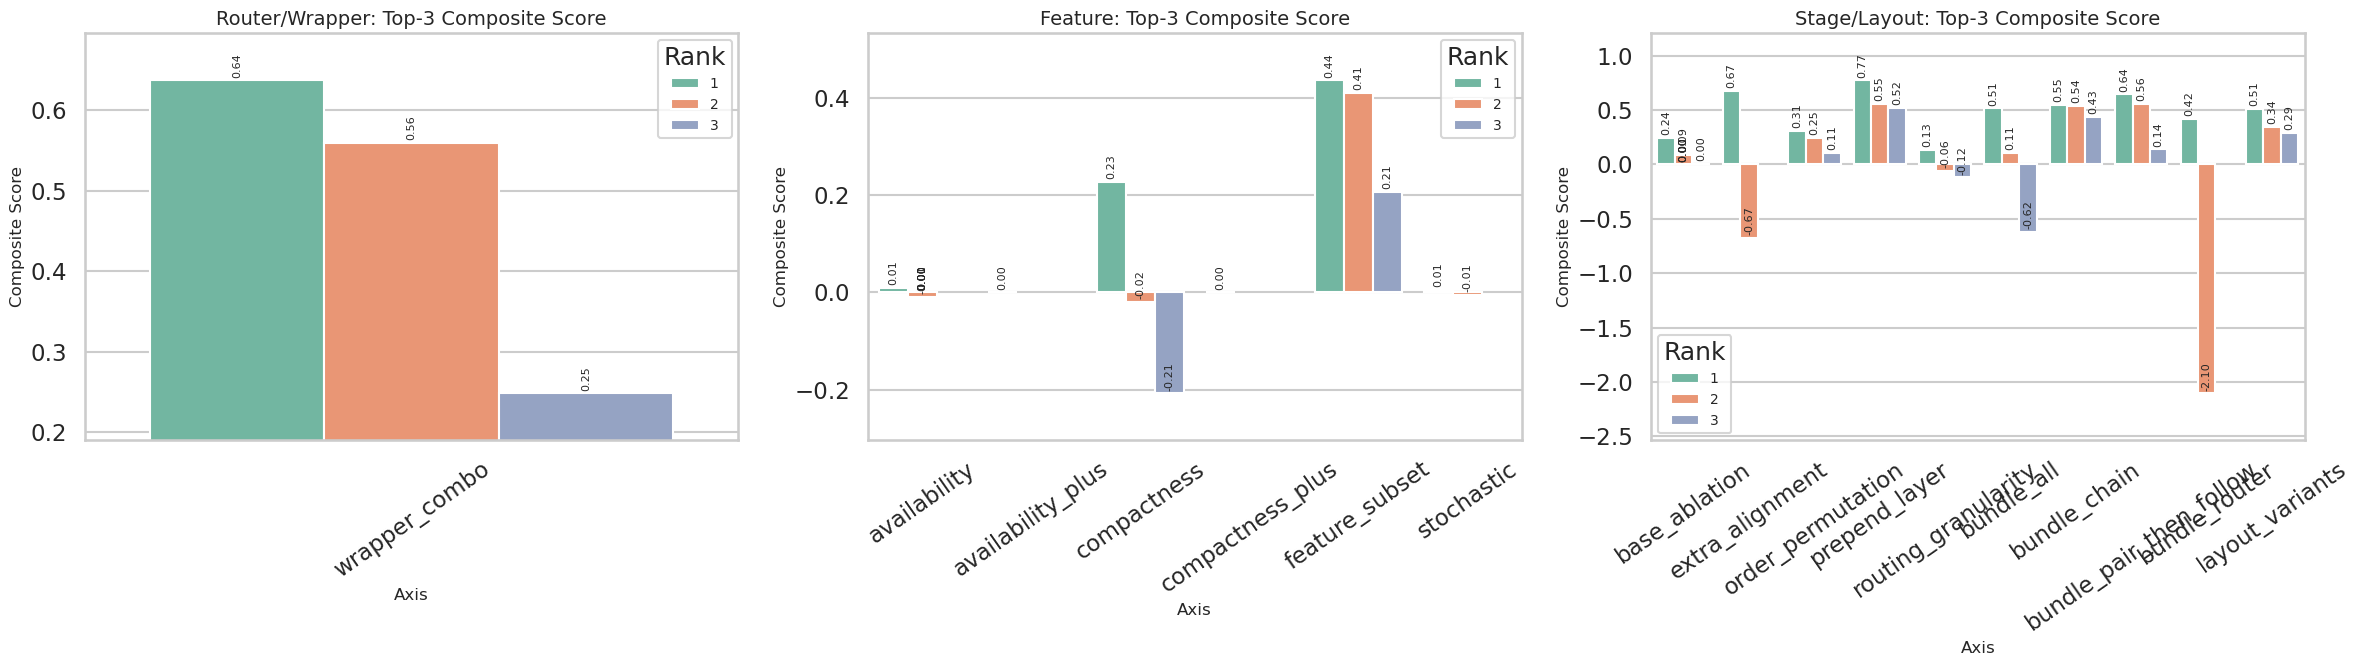

In [ ]:

def add_value_labels(ax, fmt='{:.3f}', fontsize=8):
    for p in ax.patches:
        h = p.get_height()
        if np.isnan(h):
            continue
        ax.annotate(fmt.format(h),
                    (p.get_x() + p.get_width() / 2, h),
                    ha='center', va='bottom',
                    fontsize=fontsize, rotation=90,
                    xytext=(0, 2), textcoords='offset points')

plot_df = top3.copy()
plot_df['axis_short'] = plot_df['axis_label'].str.replace('P8 ', '', regex=False).str.replace('P10 ', '', regex=False).str.replace('P11 ', '', regex=False).str.replace('P12 ', '', regex=False)
plot_df['rank'] = plot_df['rank_in_axis'].astype(int).astype(str)

families = ['Router/Wrapper','Feature','Stage/Layout']
fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=False)

for i, fam in enumerate(families):
    ax = axes[i]
    d = plot_df[plot_df['axis_family'] == fam].copy()
    if d.empty:
        ax.axis('off')
        continue
    d = d.sort_values(['axis_label','rank_in_axis'])
    sns.barplot(data=d, x='axis_short', y='composite_axis_score', hue='rank', palette='Set2', ax=ax)
    add_value_labels(ax, fmt='{:.2f}')
    ymin = d['composite_axis_score'].min()
    ymax = d['composite_axis_score'].max()
    pad = max(0.05, (ymax - ymin) * 0.15)
    ax.set_ylim(ymin - pad, ymax + pad)
    ax.set_title(f'{fam}: Top-3 Composite Score')
    ax.set_xlabel('Axis')
    ax.set_ylabel('Composite Score')
    ax.tick_params(axis='x', rotation=35)
    ax.legend(title='Rank', loc='best')

plt.tight_layout()
plt.show()



## 시각화 2: Axis Top-1 성능 (valid/test/special)

축별로 가장 좋은 1개(setting rank=1)를 뽑아, 주요 지표를 grouped bar로 비교합니다.


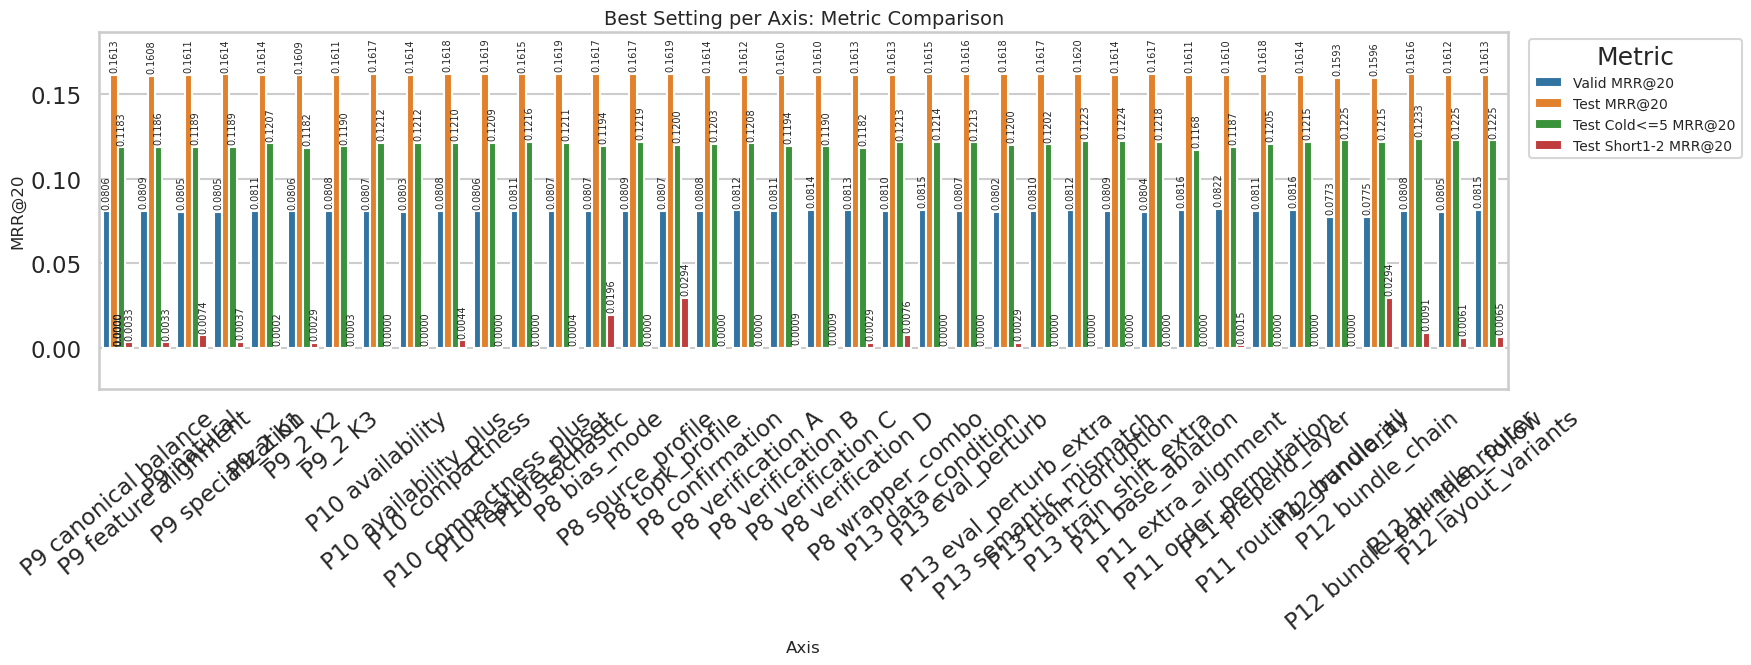

In [ ]:

best1 = top3[top3['rank_in_axis'] == 1].copy()
plot_metrics = ['valid','test','test_low','test_s12']
plot_labels = {'valid':'Valid MRR@20','test':'Test MRR@20','test_low':'Test Cold<=5 MRR@20','test_s12':'Test Short1-2 MRR@20'}

melt = best1.melt(id_vars=['axis_family','axis_label','setting_short'], value_vars=plot_metrics, var_name='metric', value_name='value')
melt['metric_name'] = melt['metric'].map(plot_labels)

fig, ax = plt.subplots(figsize=(18, 7))
sns.barplot(data=melt, x='axis_label', y='value', hue='metric_name', palette='tab10', ax=ax)
add_value_labels(ax, fmt='{:.4f}', fontsize=7)

vmin, vmax = melt['value'].min(), melt['value'].max()
pad = max(0.002, (vmax - vmin) * 0.15)
ax.set_ylim(vmin - pad, vmax + pad)
ax.set_title('Best Setting per Axis: Metric Comparison')
ax.set_xlabel('Axis')
ax.set_ylabel('MRR@20')
ax.tick_params(axis='x', rotation=40)
ax.legend(title='Metric', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()



## Final 3 Architecture Recipe 비교

`phase8_13_final_architecture.md`의 FINAL-1/2/3을 코드로 정의하고,
각 recipe를 구성하는 축별 setting 근거를 평균해서 비교합니다.

주의: 이 값은 **교차축 합성 근거 score**이며, 단일 통합 run 결과가 아닙니다.


In [ ]:

RECIPES = {
    'FINAL-1 Valid-First': {
        'P8-SCR-A': 'ALL_W5',
        'P8-SCR-C': 'MIXED_2_BIAS_GROUP_FEAT_SRC_ALL_BOTH',
        'P8-SCR-D': 'ALL_W5_BIAS_RULE_SRC_ABC_FEATURE_TK_DENSE',
        'P10-group_subset': 'FULL',
        'P10-availability': 'NO_CATEGORY',
        'P10-compactness': 'COMMON_TEMPLATE',
        'P10-stochastic': 'FEATURE_DROPOUT',
        'P11-base_ablation': 'MACRO_MID_MICRO',
        'P11-order_permutation': 'MICRO_MACRO_MID',
        'P11-routing_granularity': 'TOKEN_TOKEN_TOKEN',
        'P12-layout_variants': 'MACRO_REPEATED',
        'P12-bundle_pair_then_follow': 'BUNDLE_MACROMICRO_LEARNED',
    },
    'FINAL-2 TestSpecial-First': {
        'P8-SCR-A': 'ALL_W4',
        'P8-SCR-B': 'ALL_W5_BIAS_GROUP_FEAT_RULE',
        'P8-SCR-C': 'MIXED_2_BIAS_GROUP_FEAT_SRC_ALL_BOTH',
        'P8-SCR-D': 'ALL_W5_BIAS_RULE_SRC_ABC_FEATURE_TK_DENSE',
        'P10-group_subset': 'FULL',
        'P10-availability': 'NO_TIMESTAMP',
        'P10-compactness': 'TOP2_PER_GROUP',
        'P10-stochastic': 'FEATURE_DROPOUT',
        'P11-base_ablation': 'MID_MICRO',
        'P11-routing_granularity': 'TOKEN_TOKEN_TOKEN',
        'P12-layout_variants': 'ATTN_MICRO_BEFORE',
        'P12-bundle_pair_then_follow': 'BUNDLE_MACROMICRO_LEARNED',
    },
    'FINAL-3 Balanced': {
        'P8-SCR-A': 'ALL_W4',
        'P8-SCR-C': 'MIXED_2_BIAS_GROUP_FEAT_SRC_ALL_BOTH',
        'P8-SCR-D': 'ALL_W5_BIAS_RULE_SRC_ABC_FEATURE_TK_DENSE',
        'P10-group_subset': 'FULL',
        'P10-availability': 'NO_TIMESTAMP',
        'P10-compactness': 'TOP2_PER_GROUP',
        'P10-stochastic': 'FEATURE_DROPOUT',
        'P11-base_ablation': 'MID_MICRO',
        'P11-routing_granularity': 'TOKEN_TOKEN_TOKEN',
        'P12-layout_variants': 'MACRO_REPEATED',
        'P12-bundle_pair_then_follow': 'BUNDLE_MACROMICRO_LEARNED',
    }
}


def recipe_frame(recipe_map, summary_df):
    rows = []
    for axis, setting in recipe_map.items():
        hit = summary_df[(summary_df['axis'] == axis) & (summary_df['setting_short'] == setting)]
        if len(hit) == 0:
            continue
        rows.append(hit.iloc[0].to_dict())
    if len(rows) == 0:
        return pd.DataFrame()
    return pd.DataFrame(rows)

recipe_rows = []
for name, cfg in RECIPES.items():
    rdf = recipe_frame(cfg, summary)
    if rdf.empty:
        continue
    row = {
        'recipe': name,
        'n_axes_found': len(rdf),
        'valid': rdf['valid'].mean(),
        'test': rdf['test'].mean(),
        'test_low': rdf['test_low'].mean(),
        'test_s12': rdf['test_s12'].mean(),
        'n_eff': rdf['n_eff'].mean(),
        'ent': rdf['ent'].mean(),
        'top1': rdf['top1'].mean(),
        'intra_nn': rdf['intra_nn'].mean(),
        'feat_nn': rdf['feat_nn'].mean(),
        'group_nn': rdf['group_nn'].mean(),
        'composite_axis_score': rdf['composite_axis_score'].mean(),
    }
    recipe_rows.append(row)

recipe_df = pd.DataFrame(recipe_rows)
display(recipe_df.sort_values('recipe'))


,recipe,n_axes_found,valid,test,test_low,test_s12,n_eff,ent,top1,intra_nn,feat_nn,group_nn,composite_axis_score
0,FINAL-1 Valid-First,12,0.081223,0.161346,0.120568,0.006938,10.730742,2.148917,0.302637,0.994665,0.974071,0.996151,0.427946
1,FINAL-2 TestSpecial-First,12,0.080850,0.161688,0.121365,0.005989,11.195250,2.202224,0.318248,0.995176,0.973377,0.996774,0.476278
2,FINAL-3 Balanced,11,0.080922,0.161616,0.121564,0.005219,11.165708,2.198082,0.299212,0.995099,0.974354,0.996642,0.483705


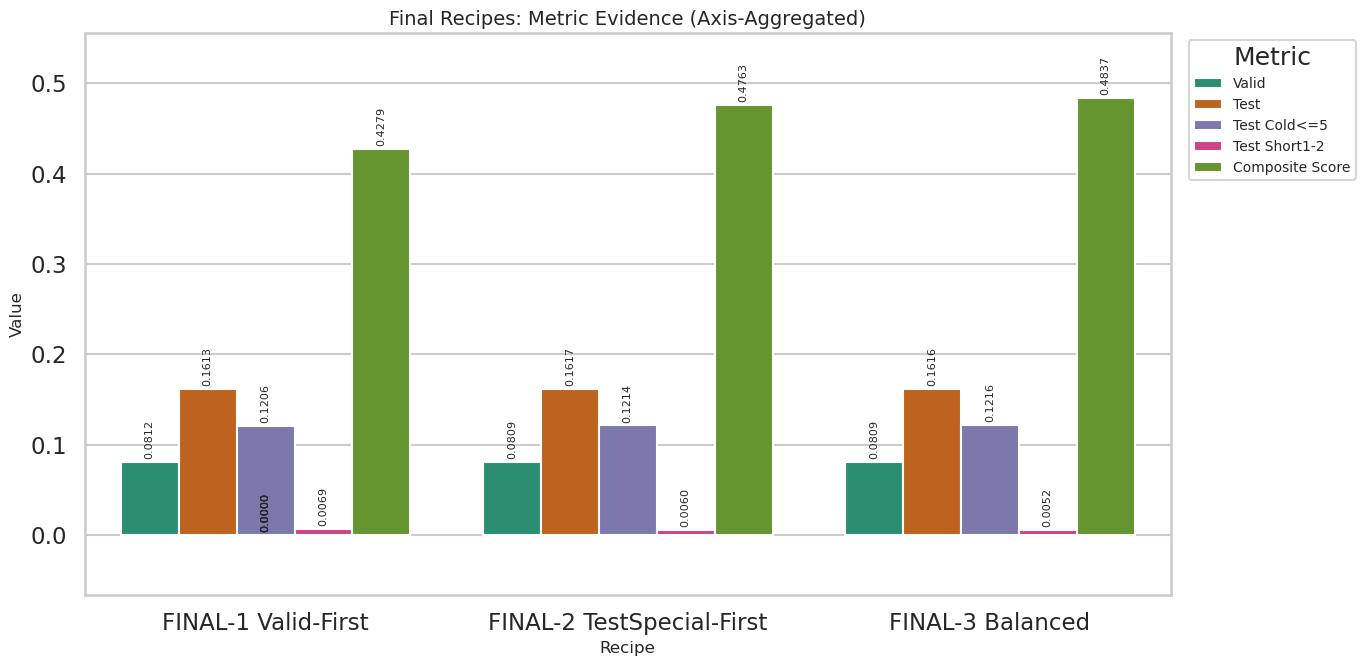

In [ ]:

# Plot recipe metric comparison
plot_cols = ['valid','test','test_low','test_s12','composite_axis_score']
plot_names = {
    'valid': 'Valid',
    'test': 'Test',
    'test_low': 'Test Cold<=5',
    'test_s12': 'Test Short1-2',
    'composite_axis_score': 'Composite Score'
}

m = recipe_df.melt(id_vars=['recipe'], value_vars=plot_cols, var_name='metric', value_name='value')
m['metric_name'] = m['metric'].map(plot_names)

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(data=m, x='recipe', y='value', hue='metric_name', palette='Dark2', ax=ax)
add_value_labels(ax, fmt='{:.4f}', fontsize=8)

vmin, vmax = m['value'].min(), m['value'].max()
pad = max(0.002, (vmax - vmin) * 0.15)
ax.set_ylim(vmin - pad, vmax + pad)
ax.set_title('Final Recipes: Metric Evidence (Axis-Aggregated)')
ax.set_xlabel('Recipe')
ax.set_ylabel('Value')
ax.legend(title='Metric', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()



## Special 시각화

special(cold/short)가 test와 어떻게 연결되는지 전체 run 관점에서 확인합니다.


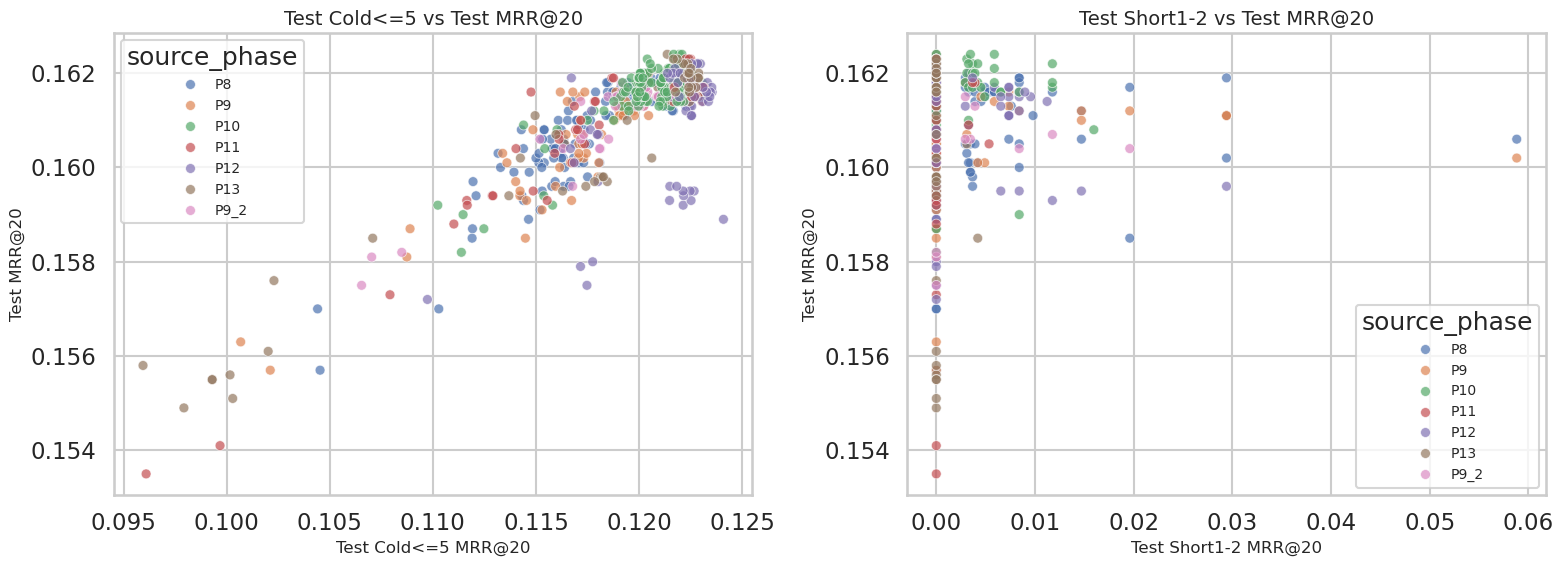

In [ ]:

sp = all_df[['source_phase','test','test_low','test_s12','valid']].copy()
sp = sp.dropna(subset=['test'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

s1 = sp.dropna(subset=['test_low'])
sns.scatterplot(data=s1, x='test_low', y='test', hue='source_phase', alpha=0.7, s=50, ax=axes[0])
axes[0].set_title('Test Cold<=5 vs Test MRR@20')
axes[0].set_xlabel('Test Cold<=5 MRR@20')
axes[0].set_ylabel('Test MRR@20')

s2 = sp.dropna(subset=['test_s12'])
sns.scatterplot(data=s2, x='test_s12', y='test', hue='source_phase', alpha=0.7, s=50, ax=axes[1])
axes[1].set_title('Test Short1-2 vs Test MRR@20')
axes[1].set_xlabel('Test Short1-2 MRR@20')
axes[1].set_ylabel('Test MRR@20')

plt.tight_layout()
plt.show()



## Diag ↔ 성능 관계 (상관)

단순 raw 상관뿐 아니라, 구조/축 영향 줄이기 위해 `axis-centered`와 `within-axis rank`도 같이 봅니다.


In [ ]:

metrics = ['n_eff','ent','top1','intra_nn','feat_nn','group_nn','expert_nn']


def spearman_no_scipy(x, y):
    d = pd.DataFrame({'x': x, 'y': y}).dropna()
    if len(d) < 5:
        return np.nan
    rx = d['x'].rank(method='average').to_numpy(dtype=float)
    ry = d['y'].rank(method='average').to_numpy(dtype=float)
    sx = rx.std(ddof=0)
    sy = ry.std(ddof=0)
    if sx == 0 or sy == 0:
        return np.nan
    return float(np.corrcoef(rx, ry)[0, 1])


rows = []
for m in metrics:
    d = all_df[[m,'valid','test','valid_centered_axis','test_centered_axis','valid_rank_axis_pct','test_rank_axis_pct']].dropna(subset=[m])

    rows.append({
        'metric': m,
        'raw_valid': spearman_no_scipy(d[m], d['valid']),
        'raw_test': spearman_no_scipy(d[m], d['test']),
        'axis_centered_valid': spearman_no_scipy(d[m], d['valid_centered_axis']),
        'axis_centered_test': spearman_no_scipy(d[m], d['test_centered_axis']),
        'axis_rank_valid': spearman_no_scipy(d[m], d['valid_rank_axis_pct']),
        'axis_rank_test': spearman_no_scipy(d[m], d['test_rank_axis_pct']),
    })

corr_df = pd.DataFrame(rows)
display(corr_df)


,metric,raw_valid,raw_test,axis_centered_valid,axis_centered_test,axis_rank_valid,axis_rank_test
0,n_eff,-0.036084,0.489747,-0.150669,0.478409,-0.176806,0.432577
1,ent,-0.064928,0.465666,-0.229268,0.484543,-0.228634,0.421356
2,top1,0.070281,-0.296892,0.035109,-0.327277,0.071643,-0.344264
3,intra_nn,-0.268014,0.559908,-0.296269,0.328075,-0.308864,0.343047
4,feat_nn,-0.163213,0.145754,-0.227657,0.027370,-0.164313,0.062801
5,group_nn,-0.159722,0.265796,-0.214030,0.131831,-0.190628,0.131699
6,expert_nn,-0.168325,0.402640,-0.214666,0.188737,-0.213251,0.201075


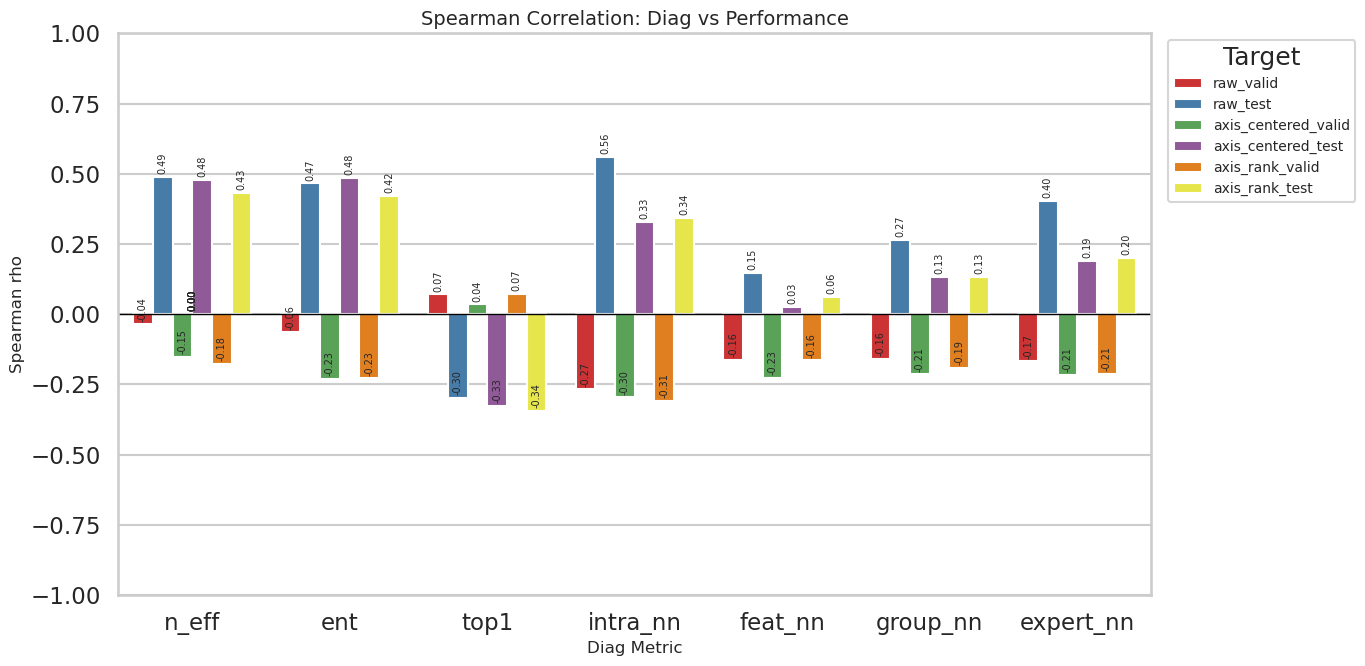

In [ ]:

plot_corr = corr_df.melt(id_vars=['metric'], var_name='target', value_name='rho')

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(data=plot_corr, x='metric', y='rho', hue='target', palette='Set1', ax=ax)
add_value_labels(ax, fmt='{:.2f}', fontsize=7)
ax.axhline(0, color='black', linewidth=1)
ax.set_ylim(-1.0, 1.0)
ax.set_title('Spearman Correlation: Diag vs Performance')
ax.set_xlabel('Diag Metric')
ax.set_ylabel('Spearman rho')
ax.legend(title='Target', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()



## Diag ↔ 상대 성능 (bin 기반)

요청하신 것처럼 “생 valid” 대신 축내 상대성능(`axis_rank_valid`, `axis_rank_test`)을 y축으로 사용합니다.

- x: diag metric (bin)
- y: axis rank percentile mean


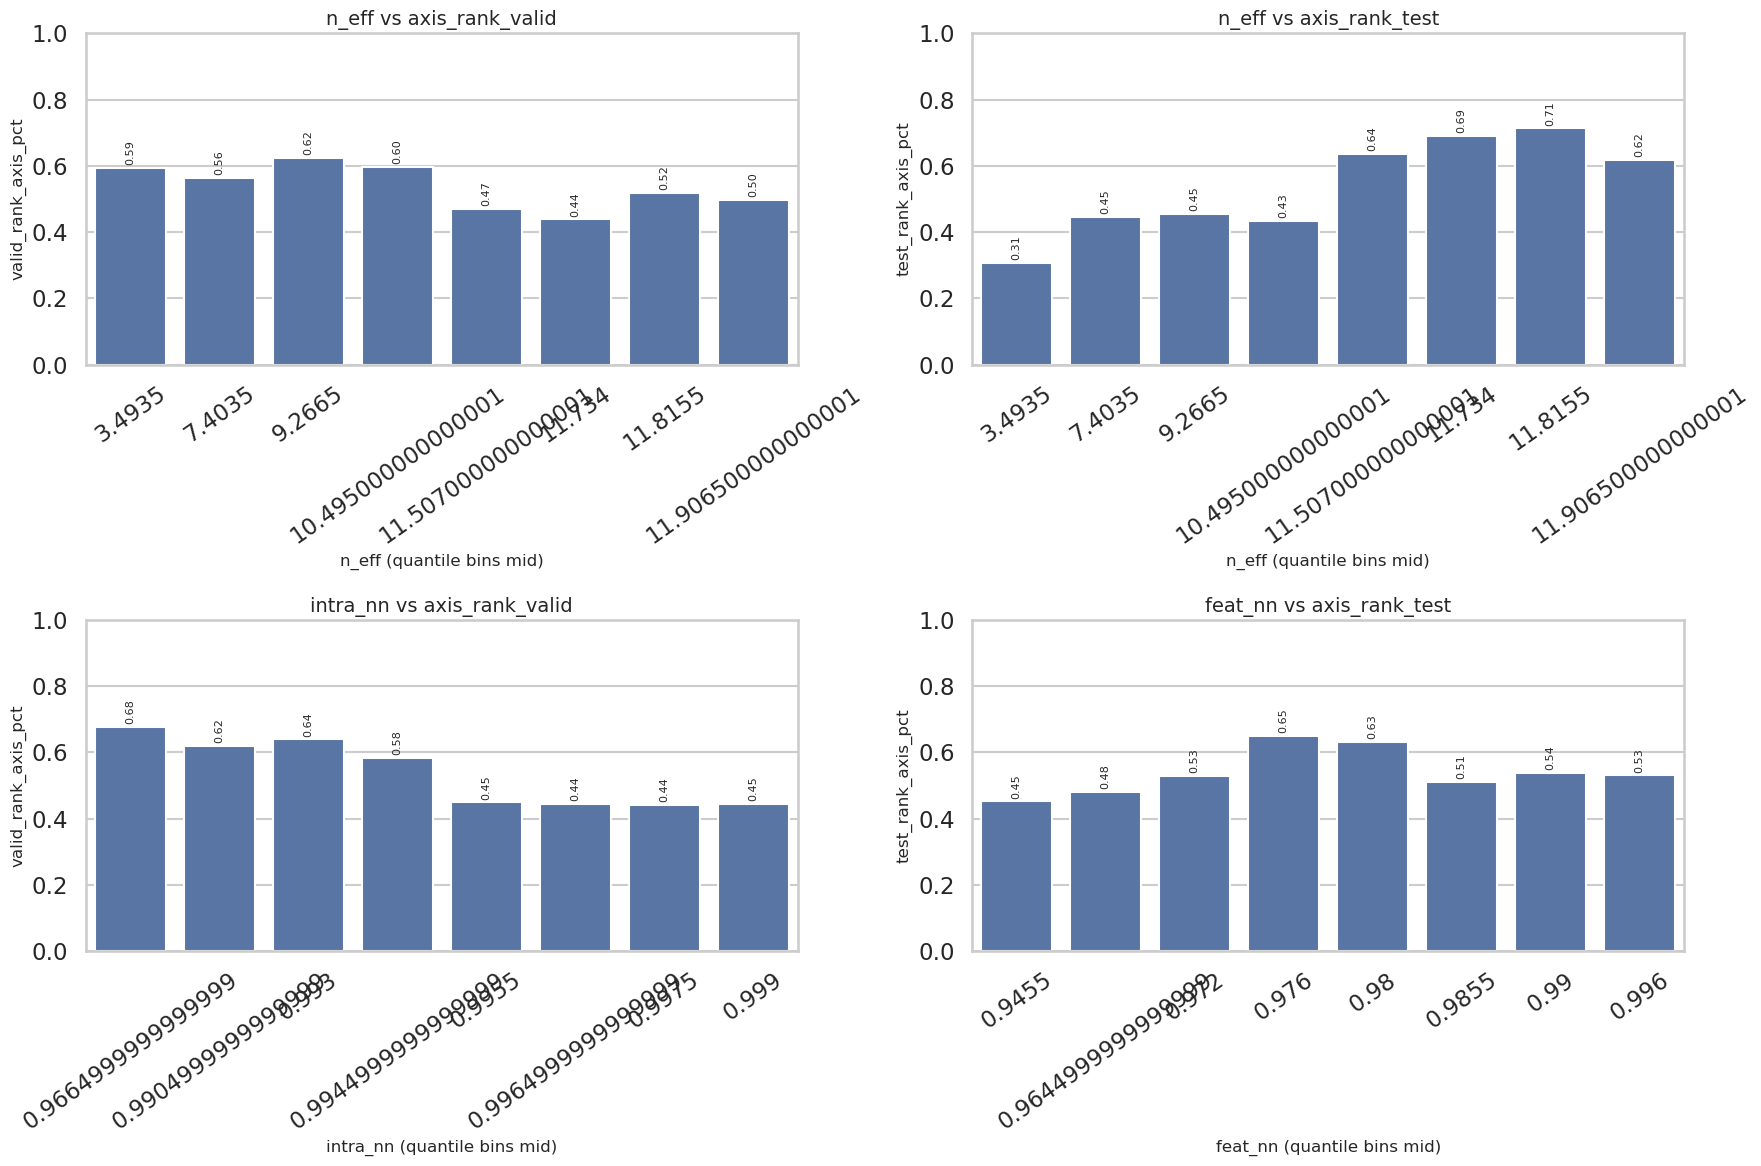

In [ ]:

def binned_rank_plot(df, x_col, y_col, ax, n_bins=8, title=''):
    d = df[[x_col, y_col]].dropna().copy()
    if len(d) < n_bins * 3:
        ax.set_title(title + ' (insufficient data)')
        return
    d['bin'] = pd.qcut(d[x_col], q=n_bins, duplicates='drop')
    g = d.groupby('bin', observed=True)[y_col].agg(['mean','count']).reset_index()
    g['bin_mid'] = [iv.mid for iv in g['bin']]
    sns.barplot(data=g, x='bin_mid', y='mean', color='#4C72B0', ax=ax)
    add_value_labels(ax, fmt='{:.2f}', fontsize=8)
    ax.set_title(title)
    ax.set_xlabel(f'{x_col} (quantile bins mid)')
    ax.set_ylabel(y_col)
    ax.set_ylim(0.0, 1.0)
    ax.tick_params(axis='x', rotation=35)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

binned_rank_plot(all_df, 'n_eff', 'valid_rank_axis_pct', axes[0,0], title='n_eff vs axis_rank_valid')
binned_rank_plot(all_df, 'n_eff', 'test_rank_axis_pct', axes[0,1], title='n_eff vs axis_rank_test')
binned_rank_plot(all_df, 'intra_nn', 'valid_rank_axis_pct', axes[1,0], title='intra_nn vs axis_rank_valid')
binned_rank_plot(all_df, 'feat_nn', 'test_rank_axis_pct', axes[1,1], title='feat_nn vs axis_rank_test')

plt.tight_layout()
plt.show()



## 산점도 (axis-centered 성능)

아래는 구조/세팅 confound를 줄이기 위해 y축을 `axis-centered test`로 둔 scatter입니다.

- n_eff / intra_nn / feat_nn / group_nn 각각에 대해 추세선(선형)을 함께 표시합니다.


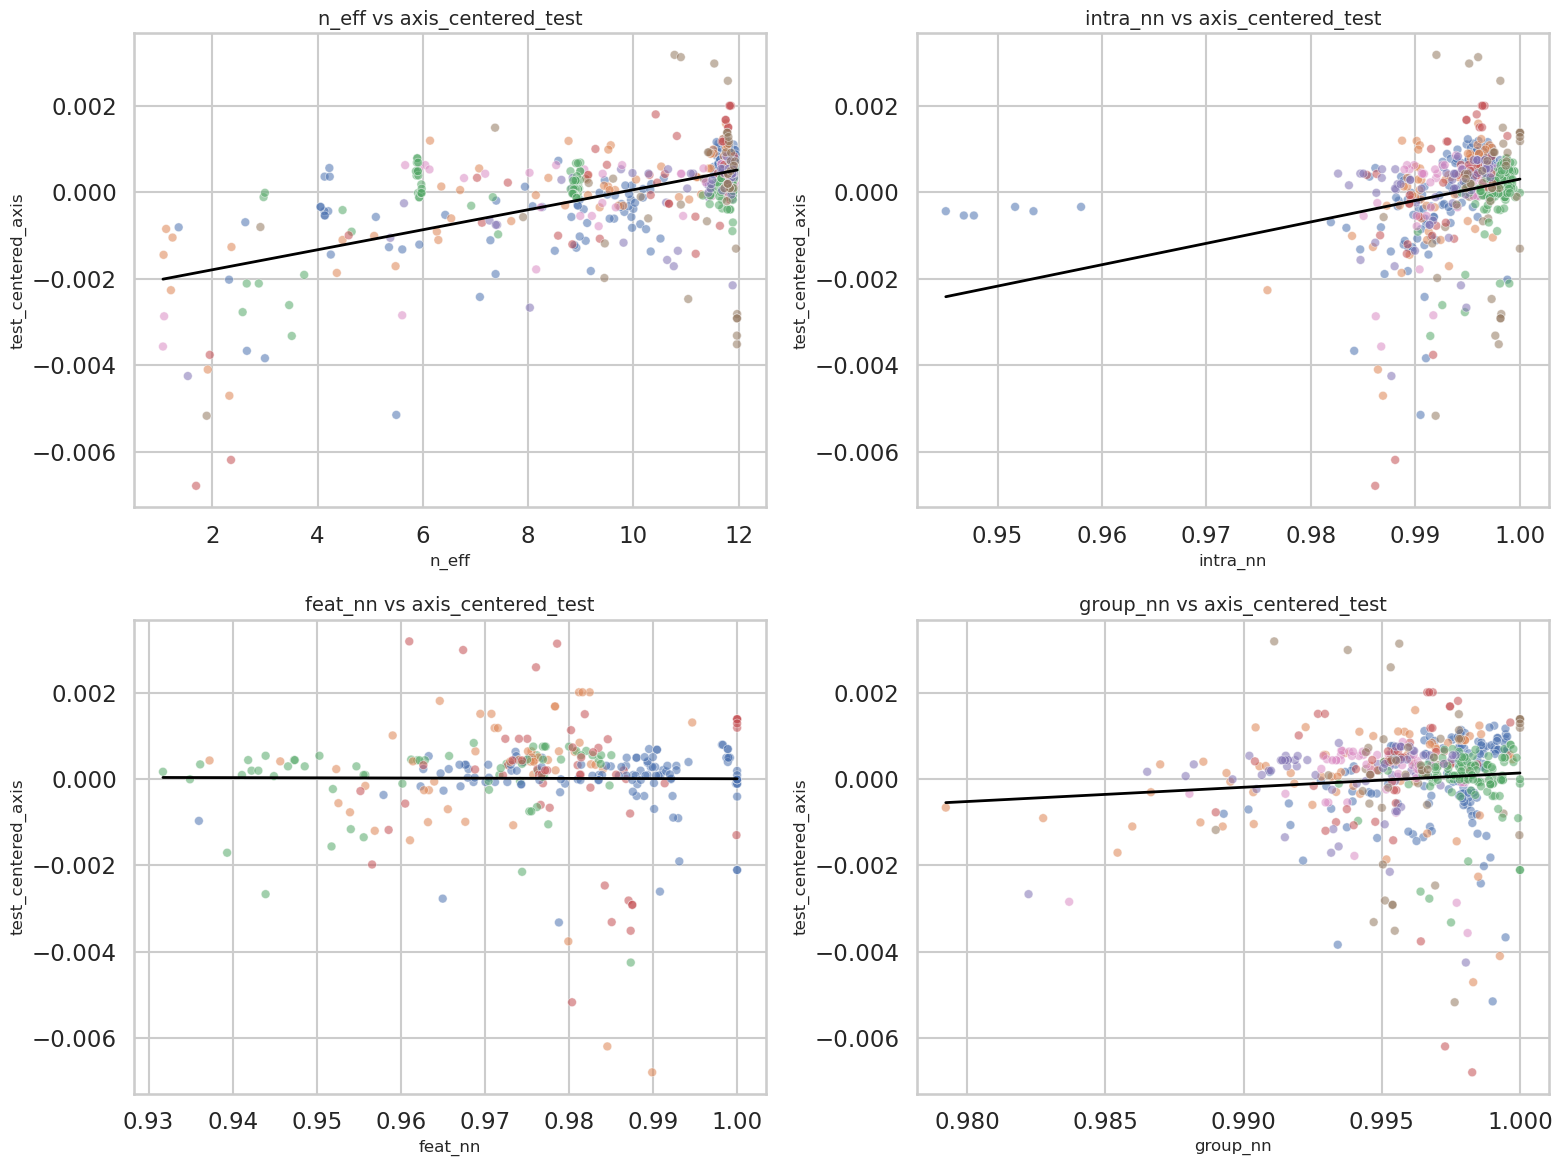

In [ ]:

def scatter_with_trend(df, x_col, y_col, ax, title):
    d = df[[x_col, y_col, 'source_phase']].dropna().copy()
    if len(d) < 10:
        ax.set_title(title + ' (insufficient data)')
        return

    sns.scatterplot(data=d, x=x_col, y=y_col, hue='source_phase', alpha=0.55, s=40, ax=ax, legend=False)

    x = d[x_col].values
    y = d[y_col].values
    if np.std(x) > 0:
        coef = np.polyfit(x, y, 1)
        xx = np.linspace(x.min(), x.max(), 100)
        yy = coef[0] * xx + coef[1]
        ax.plot(xx, yy, color='black', linewidth=2)

    ax.set_title(title)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
scatter_with_trend(all_df, 'n_eff', 'test_centered_axis', axes[0,0], 'n_eff vs axis_centered_test')
scatter_with_trend(all_df, 'intra_nn', 'test_centered_axis', axes[0,1], 'intra_nn vs axis_centered_test')
scatter_with_trend(all_df, 'feat_nn', 'test_centered_axis', axes[1,0], 'feat_nn vs axis_centered_test')
scatter_with_trend(all_df, 'group_nn', 'test_centered_axis', axes[1,1], 'group_nn vs axis_centered_test')

plt.tight_layout()
plt.show()



## 해석 가이드 (요약)

- final architecture 선택에서 핵심은 “valid 최고점 1개”보다,
  - `test/cold/special`과
  - `diag의 분산 라우팅 신호(n_eff, ent, intra_nn)`
  를 함께 보는 것입니다.
- 이 노트북의 축내 상대지표(`axis_rank_*`, `axis_centered_*`)는 다른 구조 변수 영향을 줄인 상태의 근거를 제공합니다.
- 권장 사용:
  1. 축별 top-3 bar로 후보 압축
  2. final recipe bar로 컨셉별 비교
  3. diag correlation/bin/scatter로 선택의 정당성 보강



## Bias-only Deep Dive (Stage B, test-focused)

요청하신 대로 `P8-SCR-B`(bias_mode 축)만 따로 떼어 분석합니다.

- 목적: bias 설정별 성능(test 중심) + diag 변화 + wrapper confound를 줄인 상대 성능 확인
- 포함 내용:
  - bias별 평균/최대 성능 요약
  - bias별 diag 평균 및 `bias_off` 대비 차이
  - `diag vs performance` scatter (B축 전용)
  - bias 모드별 계산식/주입 위치/유도 효과 설명(print)


In [ ]:

import textwrap

# 1) Stage-B slice only
b_df = all_df[(all_df['source_phase'].astype(str) == 'P8') & (all_df['axis'].astype(str) == 'P8-SCR-B')].copy()
if b_df.empty:
    b_df = all_df[all_df['axis'].astype(str).str.contains('P8-SCR-B', na=False)].copy()


def extract_bias_mode(row):
    explicit = str(row.get('bias_mode', '') or '').strip().lower()
    if explicit and explicit != 'nan':
        return explicit

    pool = ' '.join([
        str(row.get('setting_id', '') or ''),
        str(row.get('setting_key', '') or ''),
        str(row.get('setting_short', '') or ''),
        str(row.get('run_phase', '') or ''),
    ]).upper()

    patterns = [
        ('bias_group_feat_rule', r'BIAS[_\-]?GROUP[_\-]?FEAT[_\-]?RULE'),
        ('bias_group_feat', r'BIAS[_\-]?GROUP[_\-]?FEAT(?![_\-]?RULE)'),
        ('bias_both', r'BIAS[_\-]?BOTH'),
        ('bias_feat', r'BIAS[_\-]?FEAT'),
        ('bias_rule', r'BIAS[_\-]?RULE'),
        ('bias_off', r'BIAS[_\-]?OFF'),
    ]
    for name, pat in patterns:
        if re.search(pat, pool):
            return name
    return 'unknown'


def extract_wrapper(row):
    explicit = str(row.get('wrapper_combo', '') or '').strip().lower()
    if explicit and explicit != 'nan':
        return explicit

    pool = ' '.join([
        str(row.get('setting_id', '') or ''),
        str(row.get('setting_key', '') or ''),
        str(row.get('setting_short', '') or ''),
        str(row.get('run_phase', '') or ''),
    ]).upper()
    m = re.search(r'(ALL_W[1-6]|MIXED_[1-3])', pool)
    return m.group(1).lower() if m else 'unknown'


if b_df.empty:
    print('No rows found for P8-SCR-B. Check axis tags in source tables.')
else:
    b_df['bias_mode'] = [extract_bias_mode(r) for r in b_df.to_dict('records')]
    b_df['wrapper_combo'] = [extract_wrapper(r) for r in b_df.to_dict('records')]

    numeric_cols = [
        'valid', 'test', 'cold_core', 'short_core',
        'n_eff', 'ent', 'top1', 'expert_nn', 'intra_nn', 'feat_nn', 'group_nn'
    ]
    for c in numeric_cols:
        if c not in b_df.columns:
            b_df[c] = np.nan
        b_df[c] = pd.to_numeric(b_df[c], errors='coerce')

    # Wrapper-centered performance (controls wrapper confound within Stage-B)
    for c in ['test', 'valid', 'cold_core', 'short_core']:
        b_df[f'{c}_centered_wrapper'] = b_df[c] - b_df.groupby('wrapper_combo')[c].transform('mean')

    perf_summary = (
        b_df.groupby('bias_mode', dropna=False)
        .agg(
            n=('test', 'size'),
            test_mean=('test', 'mean'),
            test_max=('test', 'max'),
            test_std=('test', 'std'),
            valid_mean=('valid', 'mean'),
            cold_mean=('cold_core', 'mean'),
            short_mean=('short_core', 'mean'),
            test_centered_wrapper_mean=('test_centered_wrapper', 'mean'),
        )
        .sort_values('test_mean', ascending=False)
    )

    if 'bias_off' in perf_summary.index:
        base = perf_summary.loc['bias_off']
        for col in ['test_mean', 'test_max', 'valid_mean', 'cold_mean', 'short_mean', 'test_centered_wrapper_mean']:
            perf_summary[f'd_{col}_vs_off'] = perf_summary[col] - base[col]

    diag_summary = (
        b_df.groupby('bias_mode', dropna=False)[['n_eff', 'ent', 'top1', 'expert_nn', 'intra_nn', 'feat_nn', 'group_nn']]
        .mean()
        .sort_index()
    )

    ww_metrics = ['test', 'valid', 'cold_core', 'short_core', 'n_eff', 'top1', 'expert_nn', 'intra_nn', 'feat_nn', 'group_nn']
    ww = b_df.groupby(['wrapper_combo', 'bias_mode'], dropna=False)[ww_metrics].mean().reset_index()
    off = ww[ww['bias_mode'] == 'bias_off'][['wrapper_combo'] + ww_metrics].rename(
        columns={m: f'{m}_off' for m in ww_metrics}
    )
    ww_delta = ww.merge(off, on='wrapper_combo', how='left')
    for m in ww_metrics:
        ww_delta[f'd_{m}_vs_off'] = ww_delta[m] - ww_delta[f'{m}_off']

    print('=== Stage-B (bias axis) sample counts ===')
    print(b_df['bias_mode'].value_counts(dropna=False).sort_index().to_string())
    print()

    print('=== Stage-B bias performance summary (test-focused) ===')
    display(perf_summary.round(6))
    print()

    print('=== Stage-B bias diag summary (mean) ===')
    display(diag_summary.round(6))
    print()

    print('=== Within-wrapper delta vs bias_off (sorted by d_test_vs_off) ===')
    display(
        ww_delta[['wrapper_combo', 'bias_mode', 'test', 'd_test_vs_off', 'cold_core', 'd_cold_core_vs_off', 'short_core', 'd_short_core_vs_off', 'n_eff', 'd_n_eff_vs_off', 'top1', 'd_top1_vs_off', 'expert_nn', 'd_expert_nn_vs_off']]
        .sort_values(['wrapper_combo', 'd_test_vs_off'], ascending=[True, False])
        .round(6)
    )

    calc_explain = {
        'bias_off': {
            'formula': 'raw_logits_final = raw_logits_wrapper',
            'where': 'No additive bias term',
            'intent': 'Reference condition; learned wrapper logits only',
        },
        'bias_feat': {
            'formula': 'raw_logits_final += lambda_fg * log(expert_prior_from_group_features)',
            'where': 'feature_group_bias_lambda term on final expert logits',
            'intent': 'Push routing toward feature-group prior (smoother feature-aligned gating)',
        },
        'bias_group_feat': {
            'formula': 'Same computation as bias_feat in current Phase8 runner',
            'where': 'Alias mode for readability/log tracking',
            'intent': 'Same as bias_feat; naming emphasizes group-feature prior semantics',
        },
        'bias_rule': {
            'formula': 'raw_logits_final += rule_bias_scale * rule_logits',
            'where': 'rule router logits added before softmax/top-k',
            'intent': 'Encourage agreement with rule-target routing signal',
        },
        'bias_both': {
            'formula': 'Apply both feature prior term and rule logit term',
            'where': 'Both additive terms accumulated on raw_logits',
            'intent': 'Combine feature prior + rule agreement pressure',
        },
        'bias_group_feat_rule': {
            'formula': 'Same arithmetic as bias_both in current Phase8 runner',
            'where': 'Alias mode for readability/log tracking',
            'intent': 'Same as bias_both; naming emphasizes group-feature + rule interpretation',
        },
    }

    print('=== Bias mechanism and observed impact (detailed) ===')
    for mode in ['bias_off', 'bias_feat', 'bias_group_feat', 'bias_rule', 'bias_both', 'bias_group_feat_rule']:
        if mode not in perf_summary.index:
            continue
        p = perf_summary.loc[mode]
        d = diag_summary.loc[mode] if mode in diag_summary.index else pd.Series(dtype=float)
        d_test = p.get('d_test_mean_vs_off', np.nan)
        d_max = p.get('d_test_max_vs_off', np.nan)
        d_cold = p.get('d_cold_mean_vs_off', np.nan)
        d_short = p.get('d_short_mean_vs_off', np.nan)

        lines = [
            f'[Mode] {mode}',
            f"- Calculation: {calc_explain.get(mode, {}).get('formula', 'N/A')}",
            f"- Injection point: {calc_explain.get(mode, {}).get('where', 'N/A')}",
            f"- Induced behavior: {calc_explain.get(mode, {}).get('intent', 'N/A')}",
            f"- Performance (mean/max test): {p['test_mean']:.6f} / {p['test_max']:.6f}",
            f"- Delta vs off (mean/max test): {d_test:+.6f} / {d_max:+.6f}",
            f"- Delta vs off (cold/short): {d_cold:+.6f} / {d_short:+.6f}",
            f"- Diag mean: n_eff={d.get('n_eff', np.nan):.4f}, ent={d.get('ent', np.nan):.4f}, top1={d.get('top1', np.nan):.4f}, intra_nn={d.get('intra_nn', np.nan):.4f}, feat_nn={d.get('feat_nn', np.nan):.4f}, group_nn={d.get('group_nn', np.nan):.4f}",
        ]
        print('\n'.join(lines))
        print('-' * 110)

    print()
    print(textwrap.dedent('''
    Note: feature-group and rule biases are added to raw expert logits before softmax/top-k.
    Therefore final-expert diagnostics in Stage-B reflect post-bias routing behavior.
    ''').strip())


=== Stage-B (bias axis) sample counts ===
bias_mode
bias_both               4
bias_feat               4
bias_group_feat         4
bias_group_feat_rule    4
bias_off                4
bias_rule               4

=== Stage-B bias performance summary (test-focused) ===


,n,test_mean,test_max,test_std,valid_mean,cold_mean,short_mean,test_centered_wrapper_mean,d_test_mean_vs_off,d_test_max_vs_off,d_valid_mean_vs_off,d_cold_mean_vs_off,d_short_mean_vs_off,d_test_centered_wrapper_mean_vs_off
bias_mode,,,,,,,,,,,,,,
bias_off,4,0.161225,0.1619,0.000556,0.080700,0.118524,0.014706,0.000558,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
bias_feat,4,0.161150,0.1614,0.000500,0.080950,0.117621,0.000000,0.000483,-0.000075,-0.0005,0.000250,-0.000903,-0.014706,-0.000075
bias_both,4,0.160575,0.1617,0.001024,0.081100,0.117510,0.002451,-0.000092,-0.000650,-0.0002,0.000400,-0.001014,-0.012255,-0.000650
bias_group_feat_rule,4,0.160575,0.1617,0.000991,0.081225,0.116112,0.005767,-0.000092,-0.000650,-0.0002,0.000525,-0.002413,-0.008939,-0.000650
bias_group_feat,4,0.160400,0.1618,0.002280,0.081125,0.117574,0.004902,-0.000267,-0.000825,-0.0001,0.000425,-0.000950,-0.009804,-0.000825
bias_rule,4,0.160075,0.1605,0.000369,0.081500,0.116364,0.002031,-0.000592,-0.001150,-0.0014,0.000800,-0.002160,-0.012675,-0.001150



=== Stage-B bias diag summary (mean) ===


,n_eff,ent,top1,expert_nn,intra_nn,feat_nn,group_nn
bias_mode,,,,,,,
bias_both,9.394275,2.109165,0.518360,0.992496,0.993163,NaN,0.997427
bias_feat,10.455542,2.218510,0.295574,0.993037,0.994886,NaN,0.997565
bias_group_feat,9.402188,2.069747,0.489105,0.994676,0.993332,NaN,0.998679
bias_group_feat_rule,9.955223,2.087139,0.306543,0.988356,0.991266,NaN,0.996171
bias_off,10.898833,2.207449,0.256858,0.991808,0.993221,NaN,0.997494
bias_rule,8.640256,1.931698,0.315882,0.987730,0.992054,NaN,0.993862



=== Within-wrapper delta vs bias_off (sorted by d_test_vs_off) ===


,wrapper_combo,bias_mode,test,d_test_vs_off,cold_core,d_cold_core_vs_off,short_core,d_short_core_vs_off,n_eff,d_n_eff_vs_off,top1,d_top1_vs_off,expert_nn,d_expert_nn_vs_off
1,all_w2,bias_feat,0.1614,0.0004,0.116774,-0.000871,0.000000,0.000000,8.573212,-2.002810,0.371828,0.137382,0.989055,0.003024
2,all_w2,bias_group_feat,0.1612,0.0002,0.119545,0.001900,0.014706,0.014706,11.747199,1.171178,0.287003,0.052556,0.994691,0.008660
0,all_w2,bias_both,0.1611,0.0001,0.119208,0.001562,0.009804,0.009804,11.744663,1.168642,0.240470,0.006023,0.992881,0.006850
4,all_w2,bias_off,0.1610,0.0000,0.117646,0.000000,0.000000,0.000000,10.576021,0.000000,0.234447,0.000000,0.986031,0.000000
3,all_w2,bias_group_feat_rule,0.1605,-0.0005,0.116387,-0.001258,0.003460,0.003460,9.953157,-0.622864,0.243586,0.009139,0.983793,-0.002238
5,all_w2,bias_rule,0.1596,-0.0014,0.116341,-0.001305,0.000000,0.000000,10.514229,-0.061792,0.172203,-0.062244,0.984367,-0.001664
9,all_w5,bias_group_feat_rule,0.1617,0.0011,0.119373,0.004118,0.019608,-0.039216,11.601289,1.952854,0.477174,0.223012,0.996656,0.003676
8,all_w5,bias_group_feat,0.1616,0.0010,0.119365,0.004110,0.004902,-0.053922,11.591752,1.943317,0.457470,0.203308,0.996240,0.003260
10,all_w5,bias_off,0.1606,0.0000,0.115255,0.000000,0.058824,0.000000,9.648435,0.000000,0.254162,0.000000,0.992980,0.000000
11,all_w5,bias_rule,0.1605,-0.0001,0.116897,0.001642,0.003922,-0.054902,8.980511,-0.667924,0.485635,0.231473,0.991421,-0.001559


=== Bias mechanism and observed impact (detailed) ===
[Mode] bias_off
- Calculation: raw_logits_final = raw_logits_wrapper
- Injection point: No additive bias term
- Induced behavior: Reference condition; learned wrapper logits only
- Performance (mean/max test): 0.161225 / 0.161900
- Delta vs off (mean/max test): +0.000000 / +0.000000
- Delta vs off (cold/short): +0.000000 / +0.000000
- Diag mean: n_eff=10.8988, ent=2.2074, top1=0.2569, intra_nn=0.9932, feat_nn=nan, group_nn=0.9975
--------------------------------------------------------------------------------------------------------------
[Mode] bias_feat
- Calculation: raw_logits_final += lambda_fg * log(expert_prior_from_group_features)
- Injection point: feature_group_bias_lambda term on final expert logits
- Induced behavior: Push routing toward feature-group prior (smoother feature-aligned gating)
- Performance (mean/max test): 0.161150 / 0.161400
- Delta vs off (mean/max test): -0.000075 / -0.000500
- Delta vs off (cold/short)

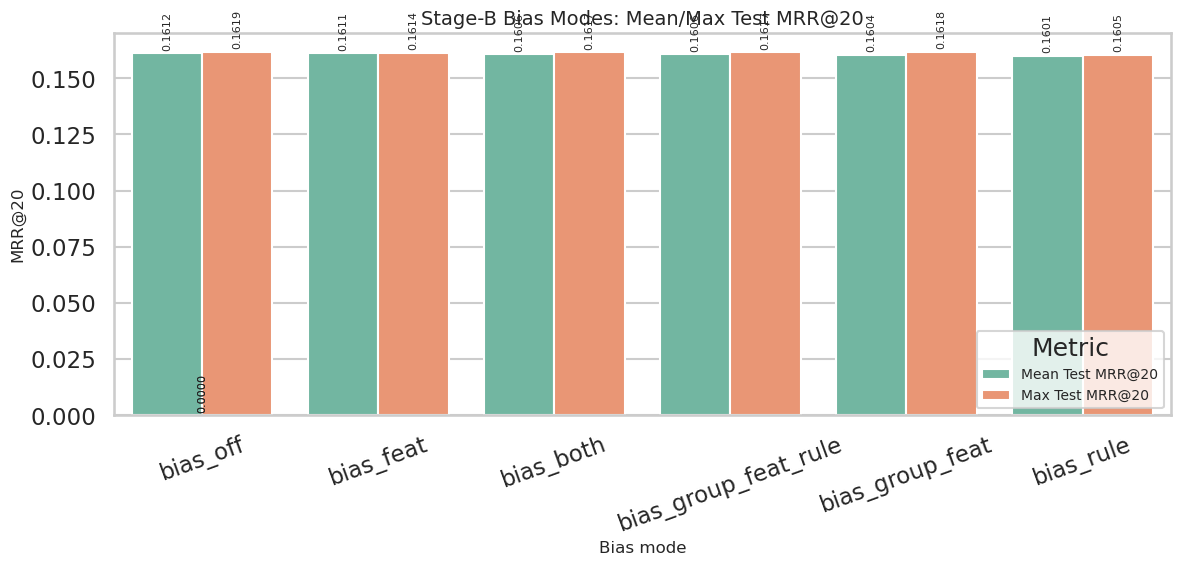

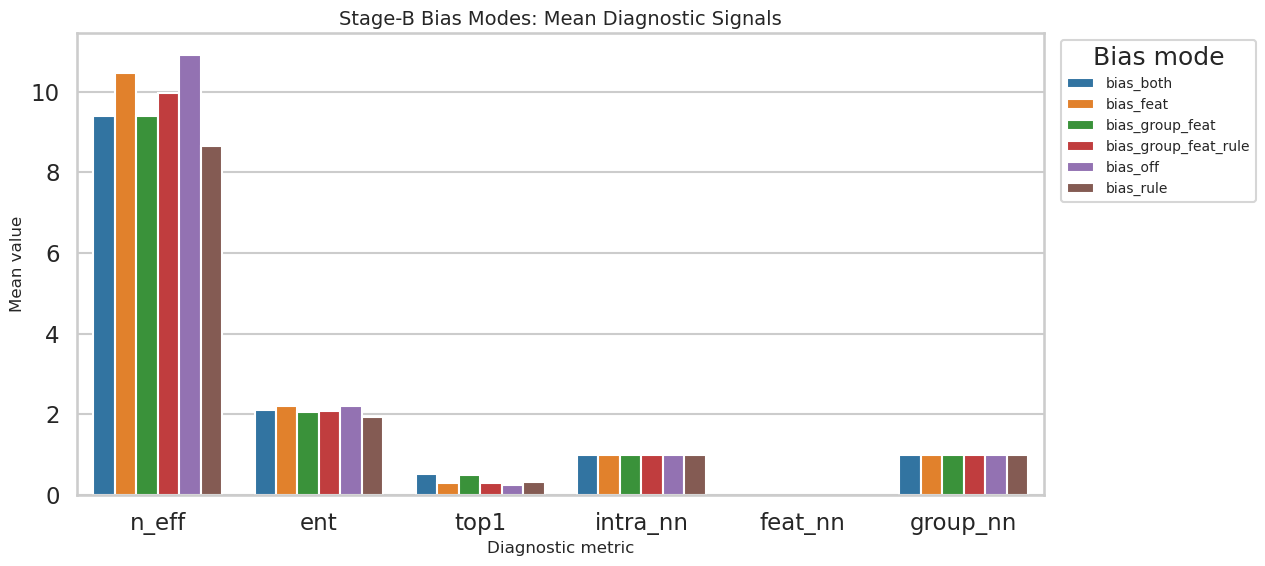

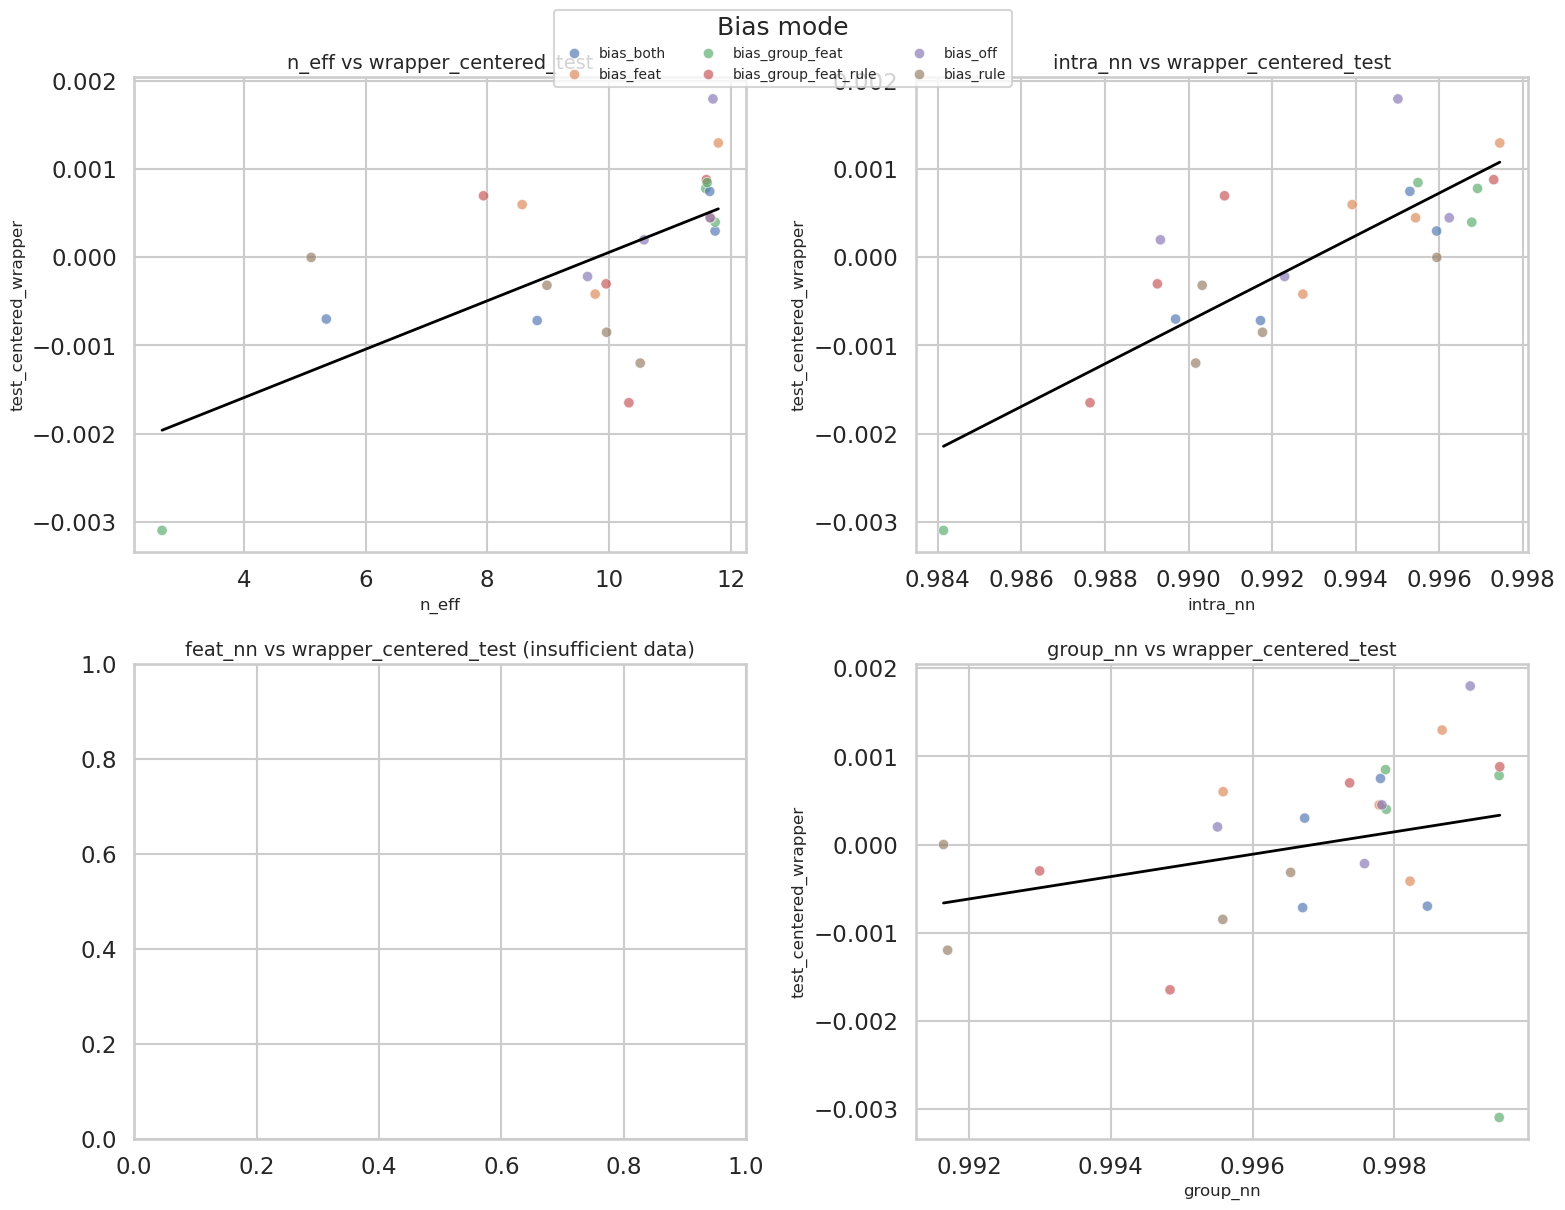

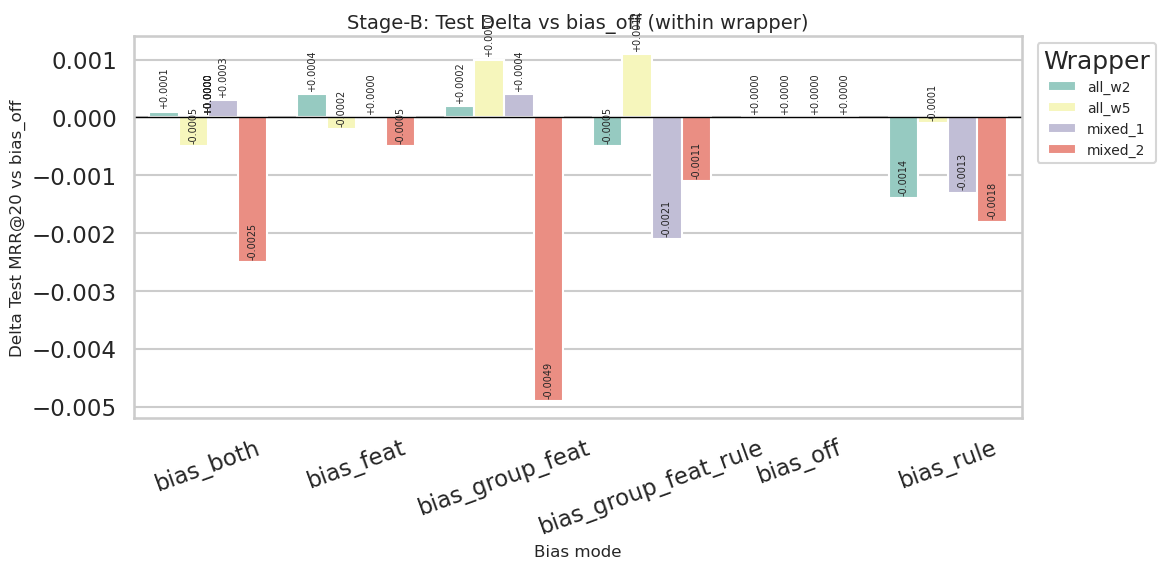

In [ ]:

if b_df.empty:
    print('No Stage-B rows to plot.')
else:
    # 1) Test-focused bar plot: mean/max by bias mode
    perf_plot = perf_summary.reset_index()[['bias_mode', 'test_mean', 'test_max']].copy()
    perf_long = perf_plot.melt(id_vars=['bias_mode'], value_vars=['test_mean', 'test_max'], var_name='metric', value_name='value')
    perf_long['metric'] = perf_long['metric'].map({'test_mean': 'Mean Test MRR@20', 'test_max': 'Max Test MRR@20'})

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=perf_long, x='bias_mode', y='value', hue='metric', palette='Set2', ax=ax)
    add_value_labels(ax, fmt='{:.4f}', fontsize=8)
    ax.set_title('Stage-B Bias Modes: Mean/Max Test MRR@20')
    ax.set_xlabel('Bias mode')
    ax.set_ylabel('MRR@20')
    ax.tick_params(axis='x', rotation=20)
    ax.legend(title='Metric', loc='best')
    plt.tight_layout()
    plt.show()

    # 2) Diag mean bar plot by bias mode
    diag_plot = diag_summary.reset_index().melt(
        id_vars=['bias_mode'],
        value_vars=['n_eff', 'ent', 'top1', 'intra_nn', 'feat_nn', 'group_nn'],
        var_name='diag',
        value_name='value',
    )

    fig, ax = plt.subplots(figsize=(13, 6))
    sns.barplot(data=diag_plot, x='diag', y='value', hue='bias_mode', palette='tab10', ax=ax)
    ax.set_title('Stage-B Bias Modes: Mean Diagnostic Signals')
    ax.set_xlabel('Diagnostic metric')
    ax.set_ylabel('Mean value')
    ax.legend(title='Bias mode', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # 3) Scatter with trend: diag vs performance (wrapper-centered test)
    def scatter_with_trend_bias(df, x_col, y_col, ax, title):
        d = df[[x_col, y_col, 'bias_mode']].dropna().copy()
        if len(d) < 8:
            ax.set_title(title + ' (insufficient data)')
            return
        sns.scatterplot(
            data=d, x=x_col, y=y_col, hue='bias_mode',
            alpha=0.65, s=55, ax=ax
        )
        x = d[x_col].to_numpy(dtype=float)
        y = d[y_col].to_numpy(dtype=float)
        if np.std(x) > 0:
            coef = np.polyfit(x, y, 1)
            xx = np.linspace(x.min(), x.max(), 100)
            yy = coef[0] * xx + coef[1]
            ax.plot(xx, yy, color='black', linewidth=2)
        ax.set_title(title)
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    scatter_with_trend_bias(b_df, 'n_eff', 'test_centered_wrapper', axes[0, 0], 'n_eff vs wrapper_centered_test')
    scatter_with_trend_bias(b_df, 'intra_nn', 'test_centered_wrapper', axes[0, 1], 'intra_nn vs wrapper_centered_test')
    scatter_with_trend_bias(b_df, 'feat_nn', 'test_centered_wrapper', axes[1, 0], 'feat_nn vs wrapper_centered_test')
    scatter_with_trend_bias(b_df, 'group_nn', 'test_centered_wrapper', axes[1, 1], 'group_nn vs wrapper_centered_test')

    handles, labels = axes[0, 0].get_legend_handles_labels()
    for ax in axes.ravel():
        if ax.get_legend() is not None:
            ax.get_legend().remove()
    fig.legend(handles, labels, title='Bias mode', loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.02))
    plt.tight_layout()
    plt.show()

    # 4) Wrapper-local delta bar plot (delta test vs bias_off)
    if 'd_test_vs_off' in ww_delta.columns:
        delta_plot = ww_delta.dropna(subset=['d_test_vs_off']).copy()
        fig, ax = plt.subplots(figsize=(12, 6))
        sns.barplot(data=delta_plot, x='bias_mode', y='d_test_vs_off', hue='wrapper_combo', palette='Set3', ax=ax)
        ax.axhline(0.0, color='black', linewidth=1)
        add_value_labels(ax, fmt='{:+.4f}', fontsize=7)
        ax.set_title('Stage-B: Test Delta vs bias_off (within wrapper)')
        ax.set_xlabel('Bias mode')
        ax.set_ylabel('Delta Test MRR@20 vs bias_off')
        ax.tick_params(axis='x', rotation=20)
        ax.legend(title='Wrapper', bbox_to_anchor=(1.01, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
